<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Módulo 2</h2><br/>
<h1>Semana 5 · Martes — Regresión Lineal y Métricas</h1>
<h3>Nuestro primer modelo de ML real</h3>
<br/>
    <b>Instructor:</b> Jesús Ortiz · jesus.jeduardo7@gmail.com<br/><br/>
    <b>SkillNest · b2b-sonda-data-science</b>
</div>
<br/>

## 🎯 Objetivos de hoy

Al final de la clase vas a poder:

1. Entender **qué es una regresión lineal** y cuándo usarla.
2. Entrenar tu **primer modelo** con `LinearRegression` de sklearn.
3. Evaluar el modelo con las **3 métricas principales**: MAE, MSE/RMSE, R².
4. **Interpretar** lo que dice cada métrica (qué tan bueno es el modelo).
5. Resolver **4 ejercicios prácticos** que veremos en vivo.

> Requisito previo: la clase del lunes (Estandarización + Train/Test).

# 1. ¿Qué es la regresión lineal?

La **regresión lineal** es el modelo más simple de Machine Learning. Predice un **número continuo** (precio, edad, ventas, temperatura) a partir de otras variables.

### 🧠 La idea con un ejemplo

Imagina que tienes pares de datos (horas estudiadas → nota obtenida):

| Horas | Nota |
|---|---|
| 1 | 3.0 |
| 2 | 4.0 |
| 3 | 5.0 |
| 4 | 6.0 |

La regresión lineal busca **la línea recta que mejor pasa por estos puntos**, con la forma:

$$ \hat{y} = a \cdot x + b $$

Donde:
- $a$ = **pendiente** (cuánto sube `y` por cada unidad de `x`)
- $b$ = **intercepto** (valor de `y` cuando `x` es 0)

En este ejemplo, la línea sería `nota = 1 × horas + 2`. Si estudio 5 horas, predigo nota 7.

### Con varias variables

$$ \hat{y} = a_1 x_1 + a_2 x_2 + a_3 x_3 + \dots + b $$

El modelo aprende un **peso** ($a_i$) para cada variable, y los suma para predecir.

### 👀 Visualización del concepto

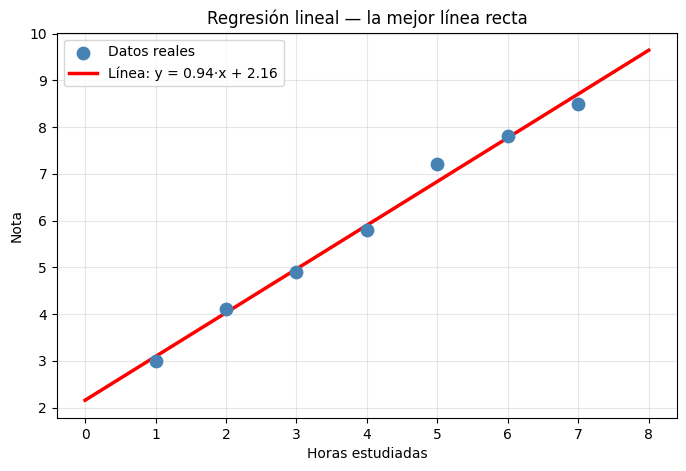

👉 Si alguien estudia 5.5 horas, predecimos nota: 7.30


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datos simulados (horas estudiadas vs nota)
horas = np.array([1, 2, 3, 4, 5, 6, 7])
nota  = np.array([3.0, 4.1, 4.9, 5.8, 7.2, 7.8, 8.5])

# La regresión lineal busca la mejor línea recta que pasa por los puntos
a, b = np.polyfit(horas, nota, 1)
x_linea = np.linspace(0, 8, 100)
y_linea = a * x_linea + b

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(horas, nota, s=80, color='steelblue', zorder=3, label='Datos reales')
ax.plot(x_linea, y_linea, color='red', linewidth=2.5, label=f'Línea: y = {a:.2f}·x + {b:.2f}')
ax.set_xlabel('Horas estudiadas')
ax.set_ylabel('Nota')
ax.set_title('Regresión lineal — la mejor línea recta')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f'👉 Si alguien estudia 5.5 horas, predecimos nota: {a*5.5 + b:.2f}')

# 2. Primer modelo con Scikit-Learn

Vamos a entrenar nuestro primer modelo **de verdad** prediciendo el precio de casas en California.

**Flujo completo (5 pasos):**

1. Cargar datos
2. Separar features (X) y target (y)
3. Dividir en train/test
4. Crear el modelo y entrenarlo (`.fit()`)
5. Predecir y evaluar (`.predict()`)

In [9]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. Cargar
df = pd.read_csv('data/housing.csv').drop(columns=['ocean_proximity','total_rooms']).dropna()

# 2. Separar features y target
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Estandarizamos (lo aprendimos ayer)
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)

# 4. Crear modelo y entrenar
modelo = LinearRegression()
modelo.fit(X_train_esc, y_train)

print('✅ Modelo entrenado')
print(f'Pendientes aprendidas: {modelo.coef_.round(2)}')
print(f'Intercepto:            {modelo.intercept_:,.2f}')

✅ Modelo entrenado
Pendientes aprendidas: [-85341.73 -90434.67  14527.41 -18174.25  48354.31 -41513.23  15739.5
  76467.24]
Intercepto:            206,644.40


In [4]:
modelo

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
# 5. Predecir con el set de test
y_pred = modelo.predict(X_test_esc)

# Comparar real vs predicho (primeras 10)
comparacion = pd.DataFrame({
    'Real':     y_test.values[:10].round(0),
    'Predicho': y_pred[:10].round(0),
    'Error':    (y_test.values[:10] - y_pred[:10]).round(0)
})
comparacion

,Real,Predicho,Error
0,245800.0,197058.0,48742.0
1,137900.0,157509.0,-19609.0
2,218200.0,202099.0,16101.0
3,220800.0,173502.0,47298.0
4,170500.0,213795.0,-43295.0
5,75000.0,108005.0,-33005.0
6,269400.0,284796.0,-15396.0
7,228900.0,249129.0,-20229.0
8,500001.0,391339.0,108662.0
9,80800.0,49301.0,31499.0


# 3. ¿Qué tan bueno es nuestro modelo? — Métricas

Tenemos predicciones — pero ¿cómo sabemos si son buenas? Para eso usamos **métricas**.

### Las 3 métricas que TIENES que conocer

| Métrica | Fórmula simple | ¿Qué mide? | ¿Cuándo se prefiere? |
|---|---|---|---|
| **MAE** (Mean Absolute Error) | promedio de \|real - predicho\| | Error promedio en las mismas unidades que `y` | Cuando todos los errores cuentan igual |
| **MSE** (Mean Squared Error) | promedio de (real - predicho)² | Error promedio elevado al cuadrado | Cuando errores grandes son MUY malos |
| **RMSE** (Root MSE) | √MSE | Como MSE pero en las unidades originales | El más usado en regresión |
| **R²** (R cuadrado) | varianza explicada | % de la varianza que el modelo captura | Para comparar modelos entre sí |

### Cómo leer R²

| R² | Significa |
|---|---|
| 1.0 | Modelo perfecto (nunca pasa en la vida real) |
| 0.7 - 0.9 | Muy buen modelo |
| 0.4 - 0.7 | Modelo decente |
| 0.0 | Predice igual que tirar el promedio |
| Negativo | El modelo es PEOR que tirar el promedio (mal) |

In [ ]:

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('📊 Evaluación del modelo')
print('─' * 50)
print(f'MAE:   {mae:>12,.0f}    (error promedio en dólares)')
print(f'MSE:   {mse:>12,.0f}    (en dólares cuadrados — difícil de leer)')
print(f'RMSE:  {rmse:>12,.0f}    (raíz del MSE → en dólares)')
print(f'R²:    {r2:>12.4f}    ({r2*100:.1f}% de la varianza explicada)')

📊 Evaluación del modelo
──────────────────────────────────────────────────
MAE:         51,373    (error promedio en dólares)
MSE:   4,921,881,238    (en dólares cuadrados — difícil de leer)
RMSE:        70,156    (raíz del MSE → en dólares)
R²:          0.6401    (64.0% de la varianza explicada)


### 👀 Visualización del rendimiento

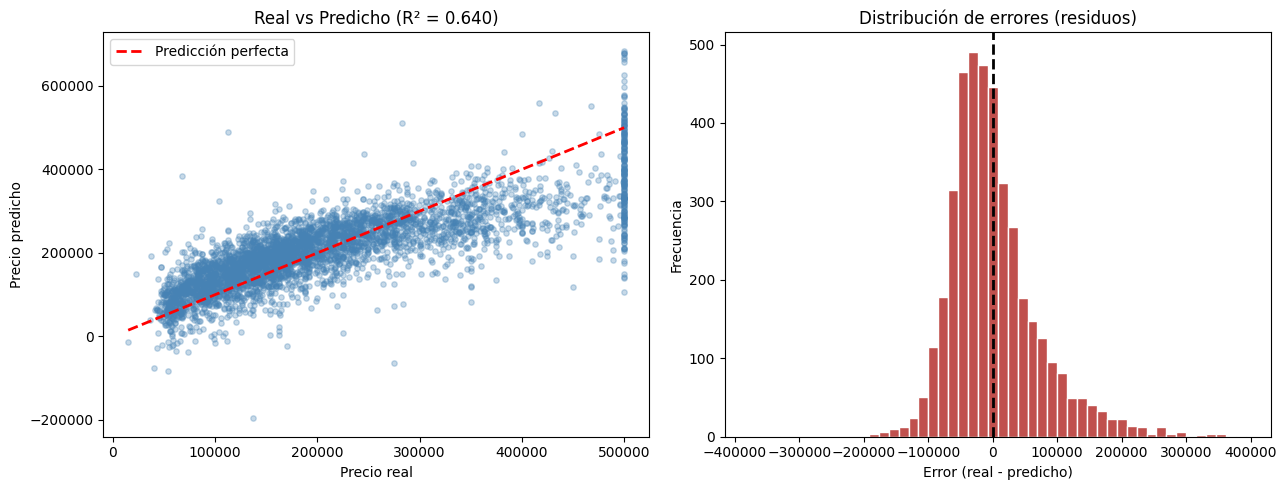

👉 Idealmente los residuos están centrados en 0 y tienen forma de campana.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Real vs Predicho — si el modelo fuera perfecto los puntos estarían en la diagonal
axes[0].scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linewidth=2, linestyle='--', label='Predicción perfecta')
axes[0].set_xlabel('Precio real')
axes[0].set_ylabel('Precio predicho')
axes[0].set_title(f'Real vs Predicho (R² = {r2:.3f})')
axes[0].legend()

# Distribución de errores (residuos)
residuos = y_test - y_pred
axes[1].hist(residuos, bins=50, color='#C0504D', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=2, linestyle='--')
axes[1].set_title('Distribución de errores (residuos)')
axes[1].set_xlabel('Error (real - predicho)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print('👉 Idealmente los residuos están centrados en 0 y tienen forma de campana.')

### 🪄 Atajo: `modelo.score()`

En sklearn, `modelo.score(X_test, y_test)` devuelve directamente el **R²**. Es el atajo más usado.

In [8]:
r2_atajo = modelo.score(X_test_esc, y_test)
print(f'R² con el atajo: {r2_atajo:.4f}')
print(f'R² calculado:    {r2:.4f}')
print('Son idénticos ✅')

R² con el atajo: 0.6401
R² calculado:    0.6401
Son idénticos ✅


---
# 🏋️ Ejercicios prácticos

**Datasets:**
- `data/housing.csv` — precios de casas (lo trabajamos hoy)
- `data/life_expectancy.csv` — esperanza de vida

> Para cada ejercicio: intenta primero, después lo revisamos juntos.

## Ejercicio 1 — Regresión simple con UNA sola variable

**Tarea:**
1. Cargar `data/housing.csv`.
2. Usar **solo la columna `median_income`** como feature (X).
3. Target: `median_house_value`.
4. Train/test split (80/20, random_state=42).
5. Entrenar `LinearRegression`.
6. Reportar el R² en el test.

**Pista:** cuando X es una sola columna, asegúrate de pasarla como DataFrame (doble corchete `df[['columna']]`).

In [ ]:
# Tu código aquí 👇



<details><summary>💡 Solución</summary>

```python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('data/housing.csv')
X = df[['median_income']]
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print(f'R²: {modelo.score(X_test, y_test):.4f}')
print(f'Pendiente: {modelo.coef_[0]:,.2f}')
print(f'Intercepto: {modelo.intercept_:,.2f}')
# El ingreso explica ~47% de la varianza del precio — buen punto de partida con una sola variable.
```
</details>

## Ejercicio 2 — Comparar las 3 métricas

**Tarea:** Usando el modelo del Ejercicio 1:

1. Calcular **MAE, RMSE y R²**.
2. Imprimir cada uno con un mensaje claro.
3. Responder en un comentario: si la mediana del precio real es $180.000, ¿el RMSE es aceptable?


In [ ]:
# Tu código aquí 👇



<details><summary>💡 Solución</summary>

```python
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modelo.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE:  {mae:,.0f}')
print(f'RMSE: {rmse:,.0f}')
print(f'R²:   {r2:.4f}')

# Si la mediana es $180.000 y el RMSE es ~80.000, el error es del 44% del precio típico.
# Es alto — con una sola variable es esperable; mañana lo mejoramos con más features.
```
</details>

## Ejercicio 3 — Multivariable: ¿mejora?

**Tarea:**
1. Usar el flujo completo con TODAS las columnas numéricas (quitando `ocean_proximity`).
2. Estandarizar correctamente (fit solo con train).
3. Entrenar `LinearRegression`.
4. Comparar el R² con el del Ejercicio 1. ¿Mejoró?

**Pista:** usa `.dropna()` para los nulos por ahora.

In [ ]:
# Tu código aquí 👇



<details><summary>💡 Solución</summary>

```python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

df = pd.read_csv('data/housing.csv').drop(columns=['ocean_proximity']).dropna()
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)

modelo = LinearRegression()
modelo.fit(X_train_esc, y_train)

print(f'R² con TODAS las features: {modelo.score(X_test_esc, y_test):.4f}')
# Suele subir a ~0.62 — mucho mejor que solo con income (~0.47).
```
</details>

## Ejercicio 4 — Aplicar todo al dataset de esperanza de vida

**Tarea:**
1. Cargar `data/life_expectancy.csv` con `index_col='CountryYear'`.
2. Quitar las columnas `Life expectancy` (target) y `Status`. Aplicar `.dropna()`.
3. Definir X (todas las restantes) y `y = Life expectancy`.
4. Train/test split 80/20, random_state=7.
5. Estandarizar correctamente.
6. Entrenar `LinearRegression`.
7. Reportar MAE, RMSE y R². ¿Es un buen modelo?
8. **Bonus:** ¿Cuál es la variable con mayor coeficiente (en valor absoluto)? Eso indica cuál es la más influyente.

In [11]:
# Tu código aquí 👇
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# 1. CARGA Y PREPARACIÓN
# ============================================================
df = pd.read_csv('data/life_expectancy.csv', index_col='CountryYear').dropna()
y = df['Life expectancy']
X = df.drop(columns=['Life expectancy', 'Status'])

print(f'Dataset: {df.shape[0]} filas × {X.shape[1]} features\n')


# ============================================================
# 2. FUNCIÓN AUXILIAR — para no repetir código
# ============================================================
def entrenar_y_evaluar(X, y, test_size, etiqueta=''):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=7
    )
    scaler = StandardScaler()
    X_train_esc = scaler.fit_transform(X_train)
    X_test_esc  = scaler.transform(X_test)

    modelo = LinearRegression().fit(X_train_esc, y_train)
    y_pred = modelo.predict(X_test_esc)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = modelo.score(X_test_esc, y_test)
    
    print(f'{etiqueta:35s} MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}')
    return modelo, X.columns


# ============================================================
# 3. COMPARAR 3 DIVISIONES TRAIN/TEST (60/40, 70/30, 80/20)
# ============================================================
print('🔹 PASO 1 — Comparando proporciones train/test (con TODAS las features)\n')

splits = [(0.4, '60/40'), (0.3, '70/30'), (0.2, '80/20')]
for test_size, etiqueta in splits:
    entrenar_y_evaluar(X, y, test_size, f'Split {etiqueta}')



# ============================================================
# 4. FEATURE IMPORTANCE — qué columnas pesan más
# ============================================================
print('🔹 PASO 2 — Calculando importancia de cada variable (coeficientes absolutos)\n')

modelo_baseline, columnas = entrenar_y_evaluar(X, y, 0.2, 'Baseline (todas features)')

# Los coeficientes nos dicen cuánto pesa cada variable
# (en valor absoluto, porque negativos también importan)
importancia = pd.Series(
    np.abs(modelo_baseline.coef_), index=columnas
).sort_values(ascending=False)

print('\nRanking de variables por importancia:')
print(importancia.round(3))

# Las menos importantes son candidatas a quitar
menos_importantes = importancia.tail(3).index.tolist()
print(f'\n👉 Las 3 menos importantes son: {menos_importantes}\n')


# ============================================================
# 5. QUITAR 1, 2, Y 3 COLUMNAS — ¿afecta el modelo?
# ============================================================
print('🔹 PASO 3 — Quitando las features menos importantes y comparando\n')

# For que va quitando columnas progresivamente
for n_quitar in [0, 1, 2, 3]:
    columnas_a_quitar = menos_importantes[:n_quitar]
    X_reducido = X.drop(columns=columnas_a_quitar)
    
    if n_quitar == 0:
        etiqueta = f'Con TODAS las {X.shape[1]} features'
    else:
        etiqueta = f'Sin {n_quitar} feature(s): {columnas_a_quitar}'
    
    entrenar_y_evaluar(X_reducido, y, 0.2, etiqueta)


# ============================================================
# 6. CONCLUSIÓN
# ============================================================
print('\n' + '='*60)
print('🎯 CONCLUSIÓN — Introducción a Feature Importance')
print('='*60)
print("""
- Los coeficientes (en valor absoluto) nos dicen qué variables pesan más.
- Quitar 1-2 variables poco importantes casi NO cambia el R² → señal de que
  esas variables no aportan información útil.
- Si quitamos MUCHAS, eventualmente el R² baja → ahí estamos perdiendo señal.
- En el mundo real, esto se usa para SIMPLIFICAR modelos:
  menos variables = más fácil de explicar, más rápido, más robusto.

Esta es la base de la 'selección de features' (feature selection),
un tema que profundizaremos más adelante en el curso.
""")



Dataset: 1649 filas × 18 features

🔹 PASO 1 — Comparando proporciones train/test (con TODAS las features)

Split 60/40                         MAE=2.71  RMSE=3.56  R²=0.8213
Split 70/30                         MAE=2.70  RMSE=3.55  R²=0.8248
Split 80/20                         MAE=2.67  RMSE=3.55  R²=0.8336
🔹 PASO 2 — Calculando importancia de cada variable (coeficientes absolutos)

Baseline (todas features)           MAE=2.67  RMSE=3.55  R²=0.8336

Ranking de variables por importancia:
under-five deaths                  11.162
infant deaths                      11.056
HIV/AIDS                            2.665
Schooling                           2.388
Adult Mortality                     2.128
Income composition of resources     1.768
BMI                                 0.752
percentage expenditure              0.517
Diphtheria                          0.324
thinness 5-9 years                  0.304
GDP                                 0.287
Polio                               0.207
Total

<details><summary>💡 Solución</summary>

```python
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('data/life_expectancy.csv', index_col='CountryYear').dropna()
X = df.drop(columns=['Life expectancy', 'Status'])
y = df['Life expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)

modelo = LinearRegression()
modelo.fit(X_train_esc, y_train)
y_pred = modelo.predict(X_test_esc)

print(f'MAE:  {mean_absolute_error(y_test, y_pred):.2f} años')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} años')
print(f'R²:   {modelo.score(X_test_esc, y_test):.4f}')

# Bonus — variable más influyente
importancia = pd.Series(np.abs(modelo.coef_), index=X.columns).sort_values(ascending=False)
print('\nTop 5 variables más influyentes:')
print(importancia.head())
```
</details>

## Ejercicio 5 — ¿Qué pasa si quitamos columnas?

Vamos a ver cuánto importa cada columna para el modelo.

**Tarea:** Con `data/housing.csv` (sin `ocean_proximity` y sin nulos):

1. Entrenar un modelo con **TODAS las columnas** y anotar el R².
2. Entrenar de nuevo, pero esta vez **sin `median_income`**. ¿Cuánto cambió el R²?
3. Entrenar de nuevo, pero esta vez **sin `longitude` ni `latitude`** (la ubicación). ¿Cuánto bajó?
4. Entrenar dejando **SOLO 3 columnas**: `median_income`, `housing_median_age` y `total_rooms`. ¿Cómo queda el R²?

**Pregunta para conversar:** ¿Cuáles columnas parecen más importantes? ¿Por qué tiene sentido?

In [ ]:
# Tu código aquí 👇



<details><summary>💡 Solución</summary>

```python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('data/housing.csv').drop(columns=['ocean_proximity']).dropna()
y = df['median_house_value']

def entrenar(X, etiqueta):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    r2 = LinearRegression().fit(X_train, y_train).score(X_test, y_test)
    print(f'{etiqueta:35s} R² = {r2:.4f}')

# 1. Todas las columnas
X_todas = df.drop(columns=['median_house_value'])
entrenar(X_todas, 'Todas las columnas')

# 2. Sin median_income
entrenar(X_todas.drop(columns=['median_income']), 'Sin median_income')

# 3. Sin ubicación
entrenar(X_todas.drop(columns=['longitude', 'latitude']), 'Sin longitude ni latitude')

# 4. Solo 3 columnas
entrenar(df[['median_income', 'housing_median_age', 'total_rooms']], 'Solo 3 columnas')

# 👉 Conclusión: median_income es la más importante.
#    Quitarla baja el R² mucho. La ubicación (lon/lat) también pesa.
#    Con solo 3 buenas columnas el modelo se acerca al de TODAS.
```
</details>

## Ejercicio 6 — Predecir y luego SIMULAR una predicción real

Hasta ahora medimos el modelo, pero no lo hemos USADO para predecir un caso nuevo. Cambiemos eso.

**Tarea:**

1. Cargar `data/housing.csv`, quitar `ocean_proximity` y nulos.
2. Definir X (todas las numéricas excepto el target) y `y = median_house_value`.
3. Train/test split (80/20, random_state=42) y entrenar `LinearRegression`.
4. **Simular una casa nueva** con estos datos y predecir su precio:

| Variable | Valor |
|---|---|
| longitude | -122.5 |
| latitude | 37.7 |
| housing_median_age | 25 |
| total_rooms | 2000 |
| total_bedrooms | 400 |
| population | 1000 |
| households | 350 |
| median_income | 5.5 |

5. Comparar el precio predicho con la mediana real del dataset. ¿Está dentro del rango razonable?
6. **Bonus:** Repetir con un `median_income = 12.0` (zona rica). ¿Sube la predicción?

In [ ]:
# Tu código aquí 👇



<details><summary>💡 Solución</summary>

```python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('data/housing.csv').drop(columns=['ocean_proximity']).dropna()
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo = LinearRegression().fit(X_train, y_train)

# Casa nueva
casa_nueva = pd.DataFrame([{
    'longitude': -122.5, 'latitude': 37.7,
    'housing_median_age': 25, 'total_rooms': 2000,
    'total_bedrooms': 400, 'population': 1000,
    'households': 350, 'median_income': 5.5
}])

prediccion = modelo.predict(casa_nueva)[0]
print(f'Precio predicho:           ${prediccion:,.0f}')
print(f'Mediana real del dataset:  ${y.median():,.0f}')
print(f'¿Está dentro del rango razonable? {y.quantile(0.10) < prediccion < y.quantile(0.90)}')

# Bonus: zona rica
casa_rica = casa_nueva.copy()
casa_rica['median_income'] = 12.0
pred_rica = modelo.predict(casa_rica)[0]
print(f'\nMisma casa con ingreso $120k: ${pred_rica:,.0f}')
print(f'Diferencia: ${pred_rica - prediccion:,.0f} 👉 el modelo aprendió que más ingreso = más precio')
```
</details>

## Ejercicio 7 — Predecir propinas en restaurantes 🍕

Cambiemos de dominio. Vamos a predecir la propina (`tip`) que deja un cliente en un restaurante.

**Dataset:** `tips` (viene con seaborn, no hay que descargar nada).

**Tarea:**

1. Cargar el dataset:
   ```python
   import seaborn as sns
   tips = sns.load_dataset('tips')
   tips.head()
   ```
2. Usar como features las columnas numéricas: `total_bill` y `size` (tamaño del grupo).
3. Target: `tip`.
4. Train/test split 80/20, random_state=42.
5. Entrenar `LinearRegression` y reportar **R² y RMSE**.
6. **Predecir** cuánta propina dejaría una mesa de 3 personas con un consumo de $50.
7. **Bonus:** hacer un scatter de `total_bill` vs `tip` con la línea del modelo encima.

In [ ]:
# Tu código aquí 👇



<details><summary>💡 Solución</summary>

```python
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

tips = sns.load_dataset('tips')

X = tips[['total_bill', 'size']]
y = tips['tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo = LinearRegression().fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print(f'R²:   {modelo.score(X_test, y_test):.4f}')
print(f'RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')

# Predicción para mesa de 3 personas con consumo de $50
caso = pd.DataFrame([{'total_bill': 50, 'size': 3}])
print(f'\nPropina predicha (bill $50, 3 personas): ${modelo.predict(caso)[0]:.2f}')

# Bonus: scatter con la línea del modelo
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(tips['total_bill'], tips['tip'], alpha=0.5, color='steelblue')
x_linea = np.linspace(tips['total_bill'].min(), tips['total_bill'].max(), 100)
# Asumimos size promedio para la línea
y_linea = modelo.predict(pd.DataFrame({'total_bill': x_linea, 'size': [tips['size'].mean()]*100}))
ax.plot(x_linea, y_linea, color='red', linewidth=2.5, label='Modelo')
ax.set_xlabel('Total bill ($)')
ax.set_ylabel('Tip ($)')
ax.set_title('Propinas vs consumo')
ax.legend(); plt.show()

# 👉 Típicamente R² ≈ 0.45 — el consumo explica buena parte de la propina,
#    pero hay variabilidad porque cada persona tiene su propia generosidad.
```
</details>

---
## 📌 Cierre del día

Hoy:

- ✅ Aprendiste qué es la **regresión lineal** y la idea de la "mejor recta"
- ✅ Entrenaste tu **primer modelo real** con `LinearRegression`
- ✅ Calculaste **MAE, MSE, RMSE y R²** y aprendiste a leerlos
- ✅ Visualizaste **real vs predicho** y la distribución de errores
- ✅ Vimos el atajo `modelo.score()` para R²

### 🔜 Próximas clases

- **Variables categóricas** (encoding con One Hot Encoder)
- **Pipelines** para automatizar todo el flujo
- **Otros modelos**: KNN, Árboles de Decisión, Random Forest
- **Optimización de hiperparámetros**

Nos vemos 🚀